In [1]:
import os
os.environ["TESINA_GPU"] = "1"
os.environ["TESINA_ROBUSTNESS"] = "1"
os.environ["TESINA_METER_SPLIT_SEED"] = "5"
print("[run-control] GPU robustness run: seed005")

[run-control] GPU robustness run: seed005


In [2]:
# === Colab bootstrap (no-op when running locally) ===========================
import os, sys, subprocess, pathlib

def _in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _in_colab():
    REPO_URL = "https://github.com/ncapac/tesina.git"
    REPO_DIR = "/content/tesina"
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(f"{REPO_DIR}/notebooks")
    try:
        import equinox  # noqa: F401
    except ImportError:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", "-r",
             f"{REPO_DIR}/requirements.txt"],
            check=True,
        )
    needed = ["data/power_data.p", "data/nwp_data.h5",
              "data/clusters.csv", "data/daily_covariates.csv",
              "data/scale_stats.json"]
    missing = [f for f in needed if not pathlib.Path(REPO_DIR, f).exists()]
    if missing:
        print("[bootstrap] WARNING — upload these to /content/tesina/data/ "
              "(via the file panel, gdown, or Drive mount) before continuing:")
        for f in missing:
            print(f"           - {f}")
    else:
        print("[bootstrap] Colab env ready — repo + deps + data all present.")


[bootstrap] Colab env ready — repo + deps + data all present.


# 03c — Conditional VAE training

Third generative baseline alongside [03a](03a_diffusion_training.ipynb)
(diffusion) and [03b](03b_rectified_flow_training.ipynb) (rectified flow).
`CVAETransformer1D` is a transformer-conditional β-VAE: it encodes the
daily profile into a Gaussian latent $q_\phi(z\mid x, c)$, then decodes
back to the profile with a transformer that cross-attends to the same
6-channel conditioning $c$ used everywhere else in this work.

Sampling does not need an iterative process — drawing $z\sim\mathcal{N}(0,I)$
and decoding once is enough — so this is the **fastest** of the three
models at inference time, at the price of typically blurrier samples than
the diffusion / RF families.

Data loading, train/val split, sanity panel and summary record are
identical to 03a/03b so the three notebooks are head-to-head comparable.


In [3]:
import sys, os, pathlib, json
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp, equinox as eqx

from src.data.loader   import load_rolle_data, compute_temp_stats, normalize_temp
from src.data.dataset  import (make_daily_instances, train_val_split_instances,
                               numpy_dataloader)
from src.models.cvae           import CVAETransformer1D
from src.training.train_cvae   import CVAETrainer
from src.runtime_paths         import DATA_DIR, OUTPUT_DIR

# ----- Runtime profile ---------------------------------------------------
GPU = bool(int(os.environ.get("TESINA_GPU", "0")))
try:
    _dev0 = jax.devices()[0].platform
except Exception:
    _dev0 = "cpu"
if not GPU and _dev0 in ("gpu", "tpu"):
    GPU = True
print(f"[runtime] jax device = {_dev0!r}  GPU profile = {GPU}")

RANDOM_SEED  = int(os.environ.get("TESINA_METER_SPLIT_SEED", os.environ.get("TESINA_SPLIT_SEED", "42")))
VAL_FRACTION = 0.15
BATCH_SIZE   = 128 if GPU else 64
ROBUSTNESS_RUN = bool(int(os.environ.get("TESINA_ROBUSTNESS", "0")))
RUN_TAG = f"seed{RANDOM_SEED:03d}"
OUTPUT_ROOT = pathlib.Path(OUTPUT_DIR)
RUN_OUTPUT_DIR = OUTPUT_ROOT / "robustness" / RUN_TAG if ROBUSTNESS_RUN else OUTPUT_ROOT
print(f"[split] meter_split_seed={RANDOM_SEED}  val_fraction={VAL_FRACTION}")
print(f"[outputs] robustness={ROBUSTNESS_RUN}  run_tag={RUN_TAG}  root={RUN_OUTPUT_DIR}")


[runtime] jax device = 'gpu'  GPU profile = True
[split] meter_split_seed=5  val_fraction=0.15
[outputs] robustness=True  run_tag=seed005  root=/content/tesina/output/robustness/seed005


## 1. Load data and the locked 6-channel conditioning vector

Mirror of [03_benchmark.ipynb](03_benchmark.ipynb) §1. On CPU the dataset
is sub-sampled to 1 000 instances; on GPU the full dataset is used.


In [4]:
# === Data: download missing raw files from Zenodo (Colab only) =============
import pathlib, subprocess

def _in_colab():
    try:
        import google.colab; return True
    except ImportError:
        return False

ZENODO_FILES = {
    "power_data.p" : "https://zenodo.org/api/records/3463137/files/power_data.p/content",
    "nwp_data.h5"  : "https://zenodo.org/api/records/3463137/files/nwp_data.h5/content",
}
_MB = {"power_data.p": 171, "nwp_data.h5": 70}

if _in_colab():
    REPO_DATA = pathlib.Path("/content/tesina/data")
    REPO_DATA.mkdir(parents=True, exist_ok=True)
    for fname, url in ZENODO_FILES.items():
        dst = REPO_DATA / fname
        if dst.exists():
            print(f"  ok  {fname} already present ({dst.stat().st_size / 1e6:.0f} MB) — skipping")
        else:
            print(f"  dl  {fname} from Zenodo (~{_MB[fname]} MB) ...")
            result = subprocess.run(["wget", "-q", "--show-progress", "-O", str(dst), url])
            if result.returncode == 0:
                print(f"  ok  {fname} saved ({dst.stat().st_size / 1e6:.0f} MB)")
            else:
                print(f"  FAIL  download failed for {fname} (exit {result.returncode})")
else:
    print("Local environment — skipping Zenodo download.")


  ok  power_data.p already present (179 MB) — skipping
  ok  nwp_data.h5 already present (73 MB) — skipping


In [5]:
from src.data.dataset import shape_normalize, split_mask_by_meter
from src.data.loader  import invert_scale_z
import json as _json

power_df, temp_daily = load_rolle_data(DATA_DIR)
temp_stats  = compute_temp_stats(temp_daily)
temp_normed = normalize_temp(temp_daily, temp_stats)

df_cl  = pd.read_csv(pathlib.Path(DATA_DIR) / 'clusters.csv')
df_cov = pd.read_csv(pathlib.Path(DATA_DIR) / 'daily_covariates.csv')
cl_lookup  = {(int(r.meter_id), r.date): int(r.cluster_id)
              for _, r in df_cl.iterrows()}
cov_lookup = {(int(r.meter_id), r.date):
              (float(r.temp_normed), float(r.log_mean_z), float(r.log_std_z))
              for _, r in df_cov.iterrows()}

# Scale stats from notebook 02 §9 — needed to denormalise back to Watts.
scale_stats = _json.loads((pathlib.Path(DATA_DIR) / 'scale_stats.json').read_text())

xs, c_disc, c_cont1, dates, meter_ids = make_daily_instances(
    power_df, temp_normed, cluster_labels=cl_lookup
)

# Per-instance shape normalisation (see notebook 01 §9).
xs, log_mean, log_std = shape_normalize(xs)

c_cont = np.zeros((len(xs), 3), dtype=np.float32)
for i, (m, d) in enumerate(zip(meter_ids, dates)):
    c_cont[i] = cov_lookup[(int(m), str(d))]

N_METERS   = int(meter_ids.max()) + 1
N_CLUSTERS = int(c_disc[:, 0].max()) + 1
print(f'Instances        : {len(xs):,}')
print(f'c_discrete shape : {c_disc.shape}  (cluster_id, day_type, season)')
print(f'c_continuous     : {c_cont.shape}  (temp_normed, log_mean_z, log_std_z)')
print(f'xs (normalised)  : {xs.shape}  '
      f'mean={xs.mean():+.2e}  std={xs.std():.3f}')
print(f'N_CLUSTERS       : {N_CLUSTERS}   N_METERS: {N_METERS}')

if not GPU:
    SUBSAMPLE_N = 1_000
    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(len(xs), size=min(SUBSAMPLE_N, len(xs)), replace=False)
    xs, c_disc, c_cont = xs[idx], c_disc[idx], c_cont[idx]
    dates, meter_ids   = dates[idx], meter_ids[idx]
    log_mean, log_std  = log_mean[idx], log_std[idx]
    print(f'[local profile] subsampled to {len(xs):,} instances')


Instances        : 8,928
c_discrete shape : (8928, 3)  (cluster_id, day_type, season)
c_continuous     : (8928, 3)  (temp_normed, log_mean_z, log_std_z)
xs (normalised)  : (8928, 24)  mean=-3.31e-09  std=1.000
N_CLUSTERS       : 5   N_METERS: 24


## 2. Train / val split + dataloaders

Same split as 03 / 03a / 03b (`seed=42`, `val_fraction=0.15`).


In [6]:
x_tr, cd_tr, cc_tr, mid_tr, x_val, cd_val, cc_val, mid_val = train_val_split_instances(
    xs, c_disc, c_cont, meter_ids,
    n_meters=N_METERS, val_fraction=VAL_FRACTION, seed=RANDOM_SEED,
)

# Reproduce the same partition for the per-instance log scales.
val_mask = split_mask_by_meter(meter_ids, n_meters=N_METERS,
                               val_fraction=VAL_FRACTION, seed=RANDOM_SEED)
log_mean_tr, log_std_tr   = log_mean[~val_mask], log_std[~val_mask]
log_mean_val, log_std_val = log_mean[val_mask],  log_std[val_mask]
print(f'Train: {len(x_tr):,}   Val: {len(x_val):,}')

train_loader = numpy_dataloader(x_tr, cd_tr, BATCH_SIZE,
                                c_continuous=cc_tr, shuffle=True)
val_loader   = numpy_dataloader(x_val, cd_val, BATCH_SIZE,
                                c_continuous=cc_val, shuffle=False)


Train: 7,440   Val: 1,488


## 3. Build CVAE model

`z_dim=64` latent, encoder/decoder share `d_model=128`. `n_continuous=3`
so the cross-attention block sees one token per continuous channel
(temp_normed, log_mean_z, log_std_z). The β-ELBO weight is `β=0.5`,
which biases the model toward reconstruction fidelity over latent
disentanglement — a sensible default for short (24-step) sequences.


In [7]:
key   = jax.random.PRNGKey(2)
model = CVAETransformer1D(
    seq_len=24, d_model=128, z_dim=64,
    n_clusters=N_CLUSTERS, n_day_types=2, n_seasons=4,
    n_continuous=c_cont.shape[1],     # 3
    beta=0.5, key=key,
)
params = sum(p.size for p in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
print(f'CVAE parameters: {params:,}')


CVAE parameters: 286,296


## 4. Train

β-ELBO objective $\mathcal{L}=\mathrm{Recon}(x,\hat x) + \beta\,\mathrm{KL}(q\Vert\mathcal{N}(0,I))$.
No CFG dropout — generation conditions are always present at sampling
time. Runtime profiles:

| profile        | steps  | epochs | warmup | patience |
|----------------|--------|--------|--------|----------|
| **`GPU=False`**| 2 000  | 3      | 50     | 3        |
| **`GPU=True`** | 50 000 | 100    | 300    | 20       |


In [8]:
ckpt_dir = RUN_OUTPUT_DIR / '03c' / 'checkpoints'
ckpt_dir.mkdir(parents=True, exist_ok=True)
# Runtime profile sets epochs + patience; total steps are derived from
# loader length so the cosine schedule matches actual training duration.
if GPU:
    N_EPOCHS, PATIENCE = 100, 20
else:
    N_EPOCHS, PATIENCE = 3, 3

steps_per_epoch = int(train_loader.epoch_len)
TOTAL_STEPS     = N_EPOCHS * steps_per_epoch
WARMUP          = max(20, int(0.05 * TOTAL_STEPS))
print(f'[schedule] steps/epoch={steps_per_epoch}  total_steps={TOTAL_STEPS}  '
      f'warmup={WARMUP}  n_epochs={N_EPOCHS}')
print(f'[checkpoint] {ckpt_dir}')

trainer = CVAETrainer(
    model=model, lr=1e-3,
    warmup_steps=WARMUP, total_steps=TOTAL_STEPS,
    checkpoint_dir=str(ckpt_dir), seed=2,
)

trainer.fit(
    train_loader, val_loader,
    n_epochs=N_EPOCHS, val_every=1, save_every=10,
    log_every_steps=200, val_batches=20, patience=PATIENCE,
)

# Persist the final model so notebooks 04/05 can load it.
trainer.save('best_model.pkl')


[schedule] steps/epoch=58  total_steps=5800  warmup=290  n_epochs=100
[checkpoint] /content/tesina/output/robustness/seed005/03c/checkpoints
Epoch   1/100  train 0.9030 (recon 0.8992  kl 0.0077)  val_loss 0.7011 (recon 0.6766  kl 0.0490)  [5.3s]
  Saved checkpoint → /content/tesina/output/robustness/seed005/03c/checkpoints/cvae_best.pkl
Epoch   2/100  train 0.3758 (recon 0.3658  kl 0.0201)  val_loss 0.3586 (recon 0.3435  kl 0.0303)  [0.3s]
  Saved checkpoint → /content/tesina/output/robustness/seed005/03c/checkpoints/cvae_best.pkl
Epoch   3/100  train 0.2555 (recon 0.2454  kl 0.0203)  val_loss 0.3009 (recon 0.2859  kl 0.0299)  [0.4s]
  Saved checkpoint → /content/tesina/output/robustness/seed005/03c/checkpoints/cvae_best.pkl
  step    200  loss 0.2321  recon 0.2081  kl 0.0481
Epoch   4/100  train 0.2212 (recon 0.1986  kl 0.0451)  val_loss 0.2669 (recon 0.2388  kl 0.0561)  [0.4s]
  Saved checkpoint → /content/tesina/output/robustness/seed005/03c/checkpoints/cvae_best.pkl
Epoch   5/100  

## 5. Training curves

Left panel: total β-ELBO loss (train + val).  Right panel: the two
components separately (reconstruction MSE and β-weighted KL). When the
KL term collapses toward zero the decoder is ignoring the latent —
watch for that under-fitting failure mode.


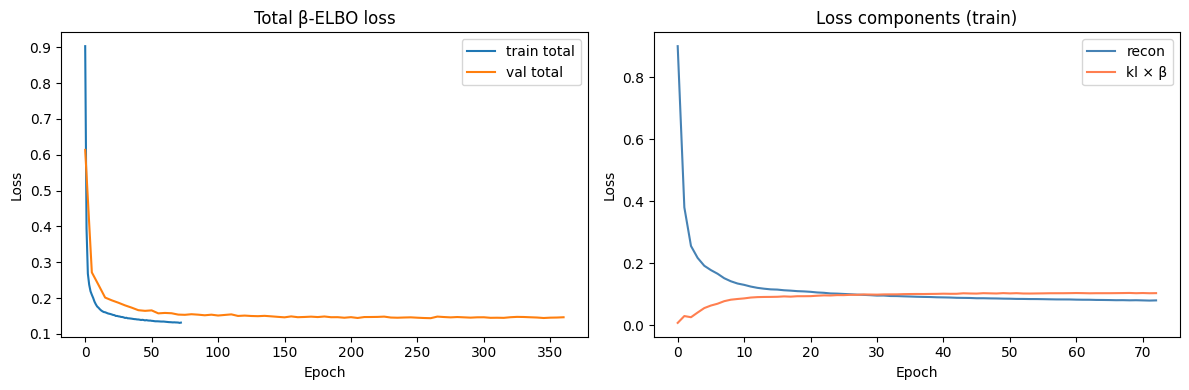

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(trainer.train_losses, label='train total')
if trainer.val_losses:
    xs_val = [i * 5 for i in range(len(trainer.val_losses))]
    axes[0].plot(xs_val, trainer.val_losses, label='val total')
axes[0].set_title('Total β-ELBO loss'); axes[0].legend()

axes[1].plot(trainer.train_recon, label='recon', color='steelblue')
axes[1].plot(trainer.train_kl,    label='kl × β', color='coral')
axes[1].set_title('Loss components (train)'); axes[1].legend()
for ax in axes: ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
plt.tight_layout(); plt.show()


train_points=62 val_points=62


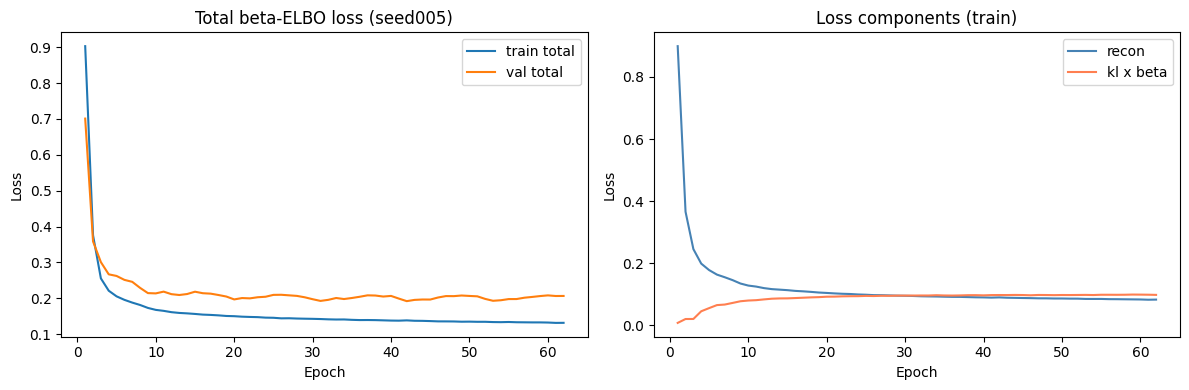

In [9]:
print(f'train_points={len(trainer.train_losses)} val_points={len(trainer.val_losses)}')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(trainer.train_losses) + 1), trainer.train_losses, label='train total')
if trainer.val_losses:
    axes[0].plot(range(1, len(trainer.val_losses) + 1), trainer.val_losses, label='val total')
axes[0].set_title('Total beta-ELBO loss (seed005)')
axes[0].legend()
axes[1].plot(range(1, len(trainer.train_recon) + 1), trainer.train_recon, label='recon', color='steelblue')
axes[1].plot(range(1, len(trainer.train_kl) + 1), trainer.train_kl, label='kl x beta', color='coral')
axes[1].set_title('Loss components (train)')
axes[1].legend()
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
plt.tight_layout()
plt.show()

## 6. Sanity-check panel — all cluster × season conditions

Same layout as 03a/03b. Samples are drawn from the prior
$z\sim\mathcal{N}(0,I)$ and decoded once — no iterative refinement.
Real validation profiles in the bottom row use the same discrete
condition for direct visual comparison.


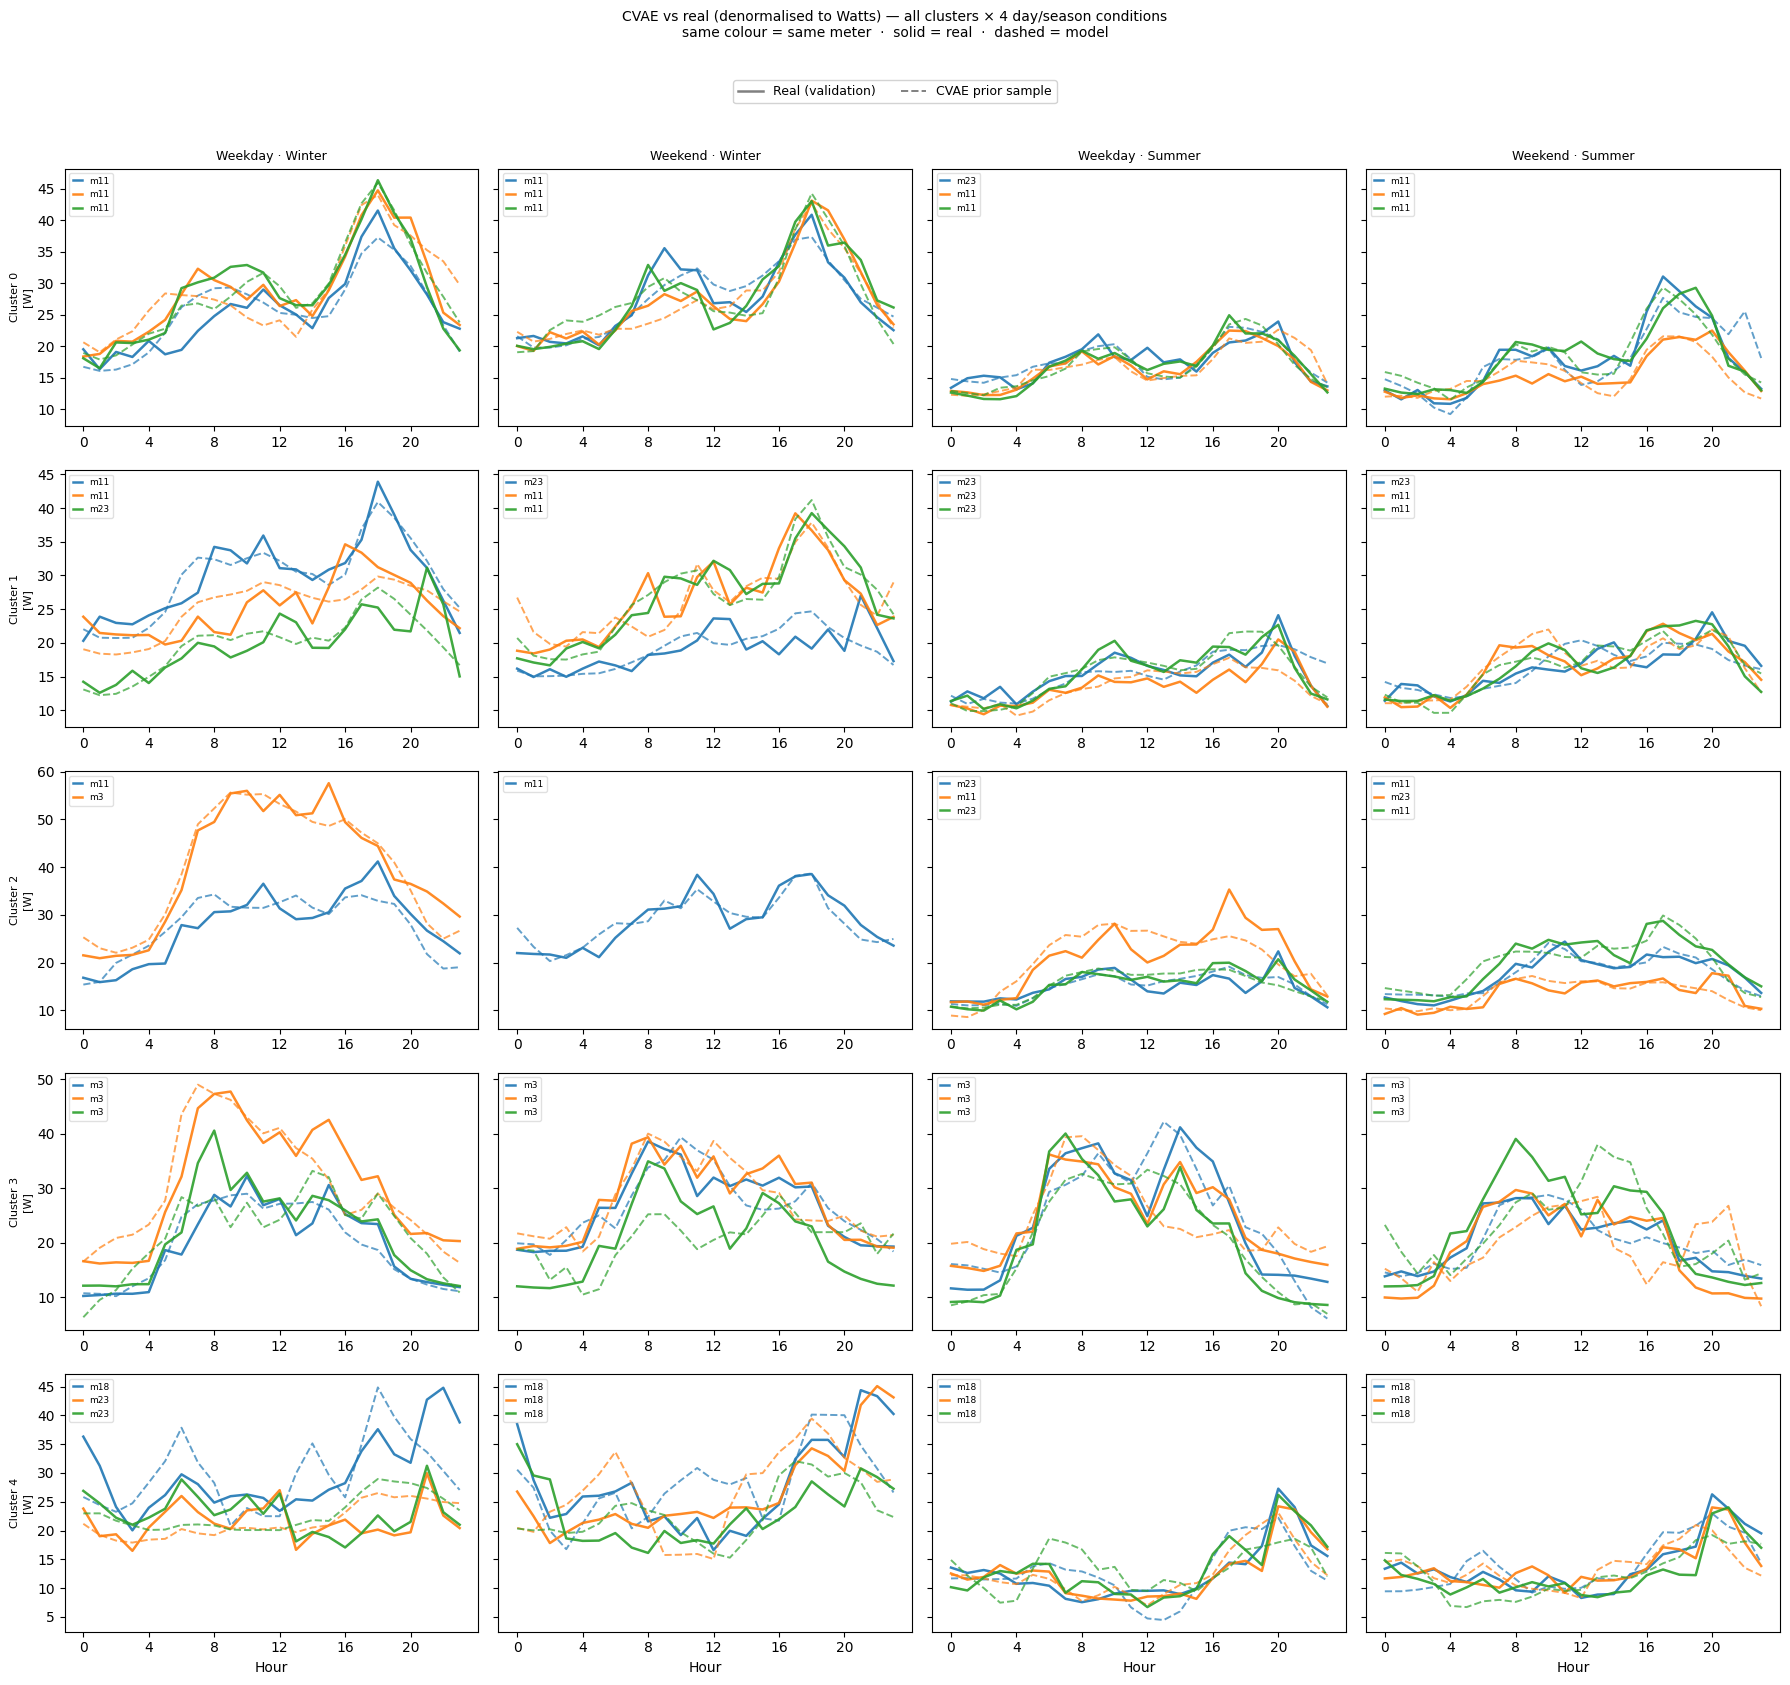

In [10]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from src.data.dataset import shape_denormalize

hours    = np.arange(24)
n_sample = 3
key_smp  = jax.random.PRNGKey(99)

day_season_specs = [
    (0, 0, 'Weekday · Winter'),
    (1, 0, 'Weekend · Winter'),
    (0, 2, 'Weekday · Summer'),
    (1, 2, 'Weekend · Summer'),
]

n_rows = N_CLUSTERS
n_cols = len(day_season_specs)
pair_colors = plt.cm.tab10(np.arange(n_sample))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4.5 * n_cols, 3.2 * n_rows),
    sharey='row',
)

for row, cid in enumerate(range(N_CLUSTERS)):
    for col, (dt, season, cond_label) in enumerate(day_season_specs):
        ax = axes[row, col]
        mask = (cd_val[:, 0] == cid) & (cd_val[:, 1] == dt) & (cd_val[:, 2] == season)

        if row == 0:
            ax.set_title(cond_label, fontsize=9)
        if col == 0:
            ax.set_ylabel(f'Cluster {cid}\n[W]', fontsize=8)
        ax.set_xticks(hours[::4])
        if row == n_rows - 1:
            ax.set_xlabel('Hour')

        if not mask.any():
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                    ha='center', va='center', fontsize=8, color='grey')
            continue

        idx    = np.where(mask)[0]
        chosen = np.random.default_rng(RANDOM_SEED + row * 100 + col).choice(
            idx, size=min(n_sample, len(idx)), replace=False
        )

        # Generate one CVAE prior sample per chosen instance using its exact cc condition.
        cd_q  = jnp.tile(jnp.array([cid, dt, season], dtype=jnp.int32), (len(chosen), 1))
        cc_q  = jnp.asarray(cc_val[chosen], dtype=jnp.float32)
        key_smp, sub = jax.random.split(key_smp)
        gen_norm = np.asarray(trainer.model.generate(cd_q, cc_q, sub))

        # Denormalise to Watts using the same per-instance scales.
        lm_q, ls_q = invert_scale_z(np.asarray(cc_q[:, 1]),
                                    np.asarray(cc_q[:, 2]), scale_stats)
        real_W = shape_denormalize(x_val[chosen],
                                   log_mean_val[chosen], log_std_val[chosen])
        gen_W  = shape_denormalize(gen_norm, lm_q, ls_q)

        for k, ci in enumerate(chosen):
            mid   = int(mid_val[ci])
            color = pair_colors[k]
            ax.plot(hours, real_W[k],
                    color=color, linewidth=1.8, linestyle='-', alpha=0.9,
                    label=f'm{mid}')
            ax.plot(hours, gen_W[k],
                    color=color, linewidth=1.4, linestyle='--', alpha=0.7,
                    label='_nolegend_')

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=6.5, loc='upper left',
                  framealpha=0.6, ncol=1, handlelength=1.0)

style_legend = [
    Line2D([0], [0], color='grey', linewidth=1.8, linestyle='-',
           label='Real (validation)'),
    Line2D([0], [0], color='grey', linewidth=1.4, linestyle='--',
           label='CVAE prior sample'),
]
fig.legend(handles=style_legend, loc='upper center', ncol=2,
           fontsize=9, bbox_to_anchor=(0.5, 1.01), framealpha=0.85)

plt.suptitle(
    'CVAE vs real (denormalised to Watts) — all clusters × 4 day/season conditions\n'
    'same colour = same meter  ·  solid = real  ·  dashed = model',
    fontsize=10, y=1.05,
)
plt.tight_layout()
plt.show()


## 7. Save training summary

Same JSON schema as 03a/03b → notebook 05 reads all three uniformly.


In [11]:
results_dir = RUN_OUTPUT_DIR / '03c' / 'results' / 'cvae'
results_dir.mkdir(parents=True, exist_ok=True)
summary_path = results_dir / 'training_summary.json'
train_meters = sorted(int(m) for m in np.unique(mid_tr))
val_meters = sorted(int(m) for m in np.unique(mid_val))

summary = {
    'model'         : 'CVAETransformer1D',
    'parametric'    : True,
    'train_instances': int(len(x_tr)),
    'val_instances' : int(len(x_val)),
    'n_clusters'    : int(N_CLUSTERS),
    'gpu_profile'   : bool(GPU),
    'total_steps'   : int(TOTAL_STEPS),
    'n_epochs_cap'  : int(N_EPOCHS),
    'c_discrete'    : ['cluster_id', 'day_type', 'season'],
    'c_continuous'  : ['temp_normed', 'log_mean_z', 'log_std_z'],
    'n_parameters'  : int(params),
    'batch_size'    : BATCH_SIZE,
    'final_train_loss': float(trainer.train_losses[-1]) if trainer.train_losses else None,
    'final_val_loss'  : float(trainer.val_losses[-1])   if trainer.val_losses   else None,
    'random_seed'   : RANDOM_SEED,
    'meter_split_seed': RANDOM_SEED,
    'val_fraction'  : VAL_FRACTION,
    'train_meters'  : train_meters,
    'val_meters'    : val_meters,
    'robustness_run': bool(ROBUSTNESS_RUN),
    'run_tag'       : RUN_TAG,
    'output_root'   : str(RUN_OUTPUT_DIR),
}
summary_path.write_text(json.dumps(summary, indent=2))
print(f'Saved → {summary_path}')
print(json.dumps(summary, indent=2))


Saved → /content/tesina/output/robustness/seed005/03c/results/cvae/training_summary.json
{
  "model": "CVAETransformer1D",
  "parametric": true,
  "train_instances": 7440,
  "val_instances": 1488,
  "n_clusters": 5,
  "gpu_profile": true,
  "total_steps": 5800,
  "n_epochs_cap": 100,
  "c_discrete": [
    "cluster_id",
    "day_type",
    "season"
  ],
  "c_continuous": [
    "temp_normed",
    "log_mean_z",
    "log_std_z"
  ],
  "n_parameters": 286296,
  "batch_size": 128,
  "final_train_loss": 0.13165258474904915,
  "final_val_loss": 0.2066002868115902,
  "random_seed": 5,
  "meter_split_seed": 5,
  "val_fraction": 0.15,
  "train_meters": [
    0,
    1,
    2,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    12,
    13,
    14,
    15,
    16,
    17,
    19,
    20,
    21,
    22
  ],
  "val_meters": [
    3,
    11,
    18,
    23
  ],
  "robustness_run": true,
  "run_tag": "seed005",
  "output_root": "/content/tesina/output/robustness/seed005"
}


In [ ]:
# === Sync GPU results to local: try several anonymous hosts ===============
# Uploads a seed-named tarball whose internal paths include output/robustness/seedXXX
# when robustness mode is enabled. Extracting from the repo root will not overwrite
# the seed-42 baseline unless TESINA_ROBUSTNESS is off.
import pathlib, subprocess, json

def _in_colab():
    try: import google.colab; return True
    except ImportError: return False

def _upload(src):
    # try bashupload.com first (tmpfiles unreachable from local)
    r = subprocess.run(["curl","-sS","-T",str(src),
                        f"https://bashupload.com/{pathlib.Path(src).name}"],
                       capture_output=True, text=True)
    for line in r.stdout.splitlines():
        if line.startswith("wget ") or line.startswith("https://"):
            return line.replace("wget ","").strip()
    # fallback: tmpfiles.org
    r = subprocess.run(["curl","-sS","-F",f"file=@{src}",
                        "https://tmpfiles.org/api/v1/upload"],
                       capture_output=True, text=True)
    try:
        j = json.loads(r.stdout)
        if j.get("status")=="success":
            u = j["data"]["url"]
            return u.replace("tmpfiles.org/", "tmpfiles.org/dl/")
    except Exception: pass
    return f"ERR bashupload={r.stdout!r}"

def _repo_rel(path, repo):
    path = pathlib.Path(path).resolve()
    try:
        return str(path.relative_to(repo.resolve()))
    except ValueError:
        return str(path)

if _in_colab():
    REPO = pathlib.Path("/content/tesina")
    to_sync = [
        _repo_rel(summary_path, REPO),
        _repo_rel(ckpt_dir / 'best_model.pkl', REPO),
        _repo_rel(ckpt_dir / 'cvae_best.pkl', REPO),
    ]
    existing = []
    for rel in to_sync:
        if (REPO / rel).exists():
            existing.append(rel)
        else:
            print(f"[skip] missing on Colab fs: {rel}")

    urls = {}
    archive = REPO / f"tesina_03c_{RUN_TAG}_results.tar.gz"
    if existing:
        subprocess.run(["tar", "-czf", str(archive), "-C", str(REPO), *existing], check=True)
        bundle_url = _upload(archive)
        if bundle_url.startswith("http"):
            urls[str(archive.name)] = bundle_url
            print(f"[bundle] {archive.name}  ->  {bundle_url}")
            print("         extract from the repo root; internal paths preserve the seed folder")
        else:
            print(f"[err] bundle: {bundle_url}")

    # Individual URLs remain available as a fallback, keyed by their intended repo path.
    for rel in existing:
        src = REPO / rel
        u = _upload(src)
        if u.startswith("http"):
            urls[rel] = u
            print(f"[ok ] {rel}  ->  {u}")
        else:
            print(f"[err] {rel}: {u}")
    print("\n=== TRANSFER MANIFEST (json) ===")
    print(json.dumps(urls, indent=2))
else:
    print("Local run — results already in place.")


[ok ] output/03c/results/cvae/training_summary.json  ->  https://tmpfiles.org/dl/wgwul80HGZXf/training_summary.json
[ok ] output/03c/checkpoints/best_model.pkl  ->  https://tmpfiles.org/dl/wdw9lc0rGQQr/best_model.pkl
[ok ] output/03c/checkpoints/cvae_best.pkl  ->  https://tmpfiles.org/dl/wrwElL0UG3IB/cvae_best.pkl

=== TRANSFER MANIFEST (json) ===
{
  "output/03c/results/cvae/training_summary.json": "https://tmpfiles.org/dl/wgwul80HGZXf/training_summary.json",
  "output/03c/checkpoints/best_model.pkl": "https://tmpfiles.org/dl/wdw9lc0rGQQr/best_model.pkl",
  "output/03c/checkpoints/cvae_best.pkl": "https://tmpfiles.org/dl/wrwElL0UG3IB/cvae_best.pkl"
}
